<a href="https://colab.research.google.com/github/navyax7/Data-Analysis-Project/blob/main/Symplfyd_KMeansClustering_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KMeans on wine dataset

In [ ]:
# Numerical libraries
import numpy as np
from sklearn.cluster import KMeans
# to handle data in form of rows and columns
import pandas as pd
# importing plotting libraries
import matplotlib.pyplot as plt
from sklearn import metrics

In [ ]:
# reading the CSV file into pandas dataframe
wine_data = pd.read_csv("winedataset.csv")
# Check top few records to get a feel of the data structure
wine_data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


K means works on X
x should be continuous
[0:11] to keep everything but quality

In [ ]:
wine_data_x = wine_data.iloc[:,0:11]
wine_data_x

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [ ]:
# Standardize the data
from sklearn.preprocessing import MinMaxScaler # Z = X-Xmin / (Xmax-Xmin)
min_max_scaler = MinMaxScaler()
wine_data_z = min_max_scaler.fit_transform(wine_data_x)
wine_data_z

array([[0.24778761, 0.39726027, 0.        , ..., 0.60629921, 0.13772455,
        0.15384615],
       [0.28318584, 0.52054795, 0.        , ..., 0.36220472, 0.20958084,
        0.21538462],
       [0.28318584, 0.43835616, 0.04      , ..., 0.40944882, 0.19161677,
        0.21538462],
       ...,
       [0.15044248, 0.26712329, 0.13      , ..., 0.53543307, 0.25149701,
        0.4       ],
       [0.11504425, 0.35958904, 0.12      , ..., 0.65354331, 0.22754491,
        0.27692308],
       [0.12389381, 0.13013699, 0.47      , ..., 0.51181102, 0.19760479,
        0.4       ]])

# KMeans Clustering

*** Every cluster is associated with three properties ***
*  1 Cluster centeroids*
*  2 cluster labels*
*  3 Cluster intertia*

In [ ]:
cluster_range = range( 2, 10)
cluster_errors = [] # distance between center of cluster and all points inside the cluster
#it is an empty box

for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, random_state = 42)
  clusters.fit(wine_data_z)
  labels = clusters.labels_                     # capture the cluster lables
  centroids = clusters.cluster_centers_         # capture the centroids
  cluster_errors.append( clusters.inertia_ )    # capture the intertia

# combine the cluster_range and cluster_errors into a dataframe by combining them
clusters_df = pd.DataFrame({ "num_clusters":cluster_range, "cluster_errors": cluster_errors})
clusters_df

,num_clusters,cluster_errors
0,2,239.183488
1,3,209.323704
2,4,183.868434
3,5,167.315205
4,6,159.172234
5,7,153.149450
6,8,146.845101
7,9,136.492769


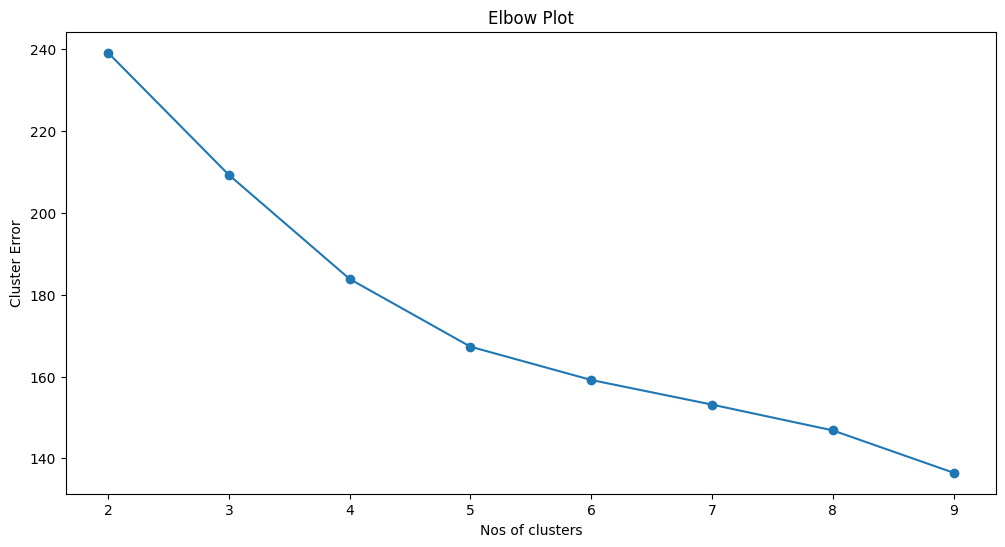

In [ ]:
# Elbow plot
# this is used to figure out how many clusters to make such that each cluster is as homogenous as possible
#here the kink point ( elbow) is 5, so we should have 5 clusters
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" );
plt.xlabel("Nos of clusters")
plt.ylabel("Cluster Error")
plt.title("Elbow Plot")
plt.show()

In [ ]:
# The elbow plot shows that 7 might be a good choice for K and it seems logical given we know there are 7 qualities of wine

In [ ]:
cluster = KMeans( n_clusters = 6, random_state = 42 )
cluster.fit(wine_data_z)

KMeans(n_clusters=6, random_state=42)

# Every cluster gets associated with a lable, centroid and intertia....

In [ ]:
# Get the centroids.... using function cluster_centers_
centroids = cluster.cluster_centers_
centroids

array([[0.2570345 , 0.35972882, 0.10271429, 0.09286413, 0.12040476,
        0.15250072, 0.1055816 , 0.48513141, 0.49354009, 0.1566296 ,
        0.22833072],
       [0.16095133, 0.33727526, 0.08421875, 0.09143122, 0.0933935 ,
        0.25579519, 0.13169906, 0.30843123, 0.59498031, 0.18151198,
        0.50848024],
       [0.61660468, 0.19806763, 0.54927536, 0.14231355, 0.12324889,
        0.134109  , 0.08825387, 0.65622805, 0.31393358, 0.23657034,
        0.33813948],
       [0.33422882, 0.15400257, 0.41053571, 0.10387109, 0.1026264 ,
        0.17489311, 0.08960121, 0.37568177, 0.42829021, 0.22607464,
        0.50968407],
       [0.31657146, 0.28229945, 0.29397993, 0.15774041, 0.12586194,
        0.39314146, 0.30037699, 0.54239044, 0.4352303 , 0.18008131,
        0.2136695 ],
       [0.38682504, 0.24448758, 0.39160428, 0.08841843, 0.2052976 ,
        0.14265271, 0.12554562, 0.56015061, 0.38468988, 0.2628006 ,
        0.21439737]])

In [ ]:
# Let us put the raw centroid values into a dataframe under respective columns
centroid_df = pd.DataFrame(centroids, columns = list(wine_data_z) )
centroid_df

,0.247788,0.397260,0.000000,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
,0.283186,0.520548,0.000000,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
,0.283186,0.438356,0.040000,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
,0.584071,0.109589,0.560000,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385
,0.247788,0.397260,0.000000,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
,0.247788,0.369863,0.000000,0.061644,0.105175,0.169014,0.120141,0.567548,0.606299,0.137725,0.153846
,0.292035,0.328767,0.060000,0.047945,0.095159,0.197183,0.187279,0.464758,0.440945,0.077844,0.153846
,0.238938,0.363014,0.000000,0.020548,0.088481,0.197183,0.053004,0.332599,0.511811,0.083832,0.246154
,0.283186,0.315068,0.020000,0.075342,0.101836,0.112676,0.042403,0.494126,0.488189,0.143713,0.169231
,0.256637,0.260274,0.360000,0.356164,0.098497,0.225352,0.339223,0.567548,0.480315,0.281437,0.323077
,0.185841,0.315068,0.080000,0.061644,0.141903,0.197183,0.208481,0.428047,0.425197,0.125749,0.123077


In [ ]:
prediction=cluster.predict(wine_data_z) # Is to predict in which cluster each wine will go
# Once the cluster numbers are predicted, I want to insert a new column in my data set
# Called Group and here I will put the cluster number
wine_data["Group"] = pd.DataFrame(prediction, columns =["Group"])
wine_data.to_csv('results.csv')

In [ ]:
prediction=cluster.predict(wine_data_z) # Is to predict in which cluster each wine will go
# Once the cluster numbers are predicted, I want to insert a new column in my data set
# Called Group and here I will put the cluster number
wine_data["Group"] = pd.DataFrame(prediction, columns =["Group"])
wine_data.to_csv('results.csv')
# Print the first 20 elements in the dataframe to verify if the cluster numbers appear under column Group
print(wine_data.head(20))
# Count the number of wines in each Cluster
print(wine_data.groupby("Group").count())
# Based on the wine quality group the wines and see how many wines are in each "Quality"
print(wine_data.groupby("quality").count())

    fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0             7.4             0.700         0.00             1.9      0.076   
1             7.8             0.880         0.00             2.6      0.098   
2             7.8             0.760         0.04             2.3      0.092   
3            11.2             0.280         0.56             1.9      0.075   
4             7.4             0.700         0.00             1.9      0.076   
5             7.4             0.660         0.00             1.8      0.075   
6             7.9             0.600         0.06             1.6      0.069   
7             7.3             0.650         0.00             1.2      0.065   
8             7.8             0.580         0.02             2.0      0.073   
9             7.5             0.500         0.36             6.1      0.071   
10            6.7             0.580         0.08             1.8      0.097   
11            7.5             0.500         0.36    

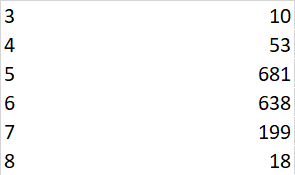